In [9]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import Physicalfunctions as pf
import Physicalparameters as pp
import time 

In [10]:
# READ AND CHARGE DATA
df = pd.read_csv("double_pendulum_dataset.csv")
# BUILD t VECTOR
N = len(df)
t = torch.linspace(0, (N-1)*pp.dt, N).view(-1, 1)

# EXCTRACT COLUMNS
theta1 = torch.tensor(df["theta1"].values).view(-1, 1)
theta2 = torch.tensor(df["theta2"].values).view(-1, 1)
omega1 = torch.tensor(df["omega1"].values).view(-1, 1)
omega2 = torch.tensor(df["omega2"].values).view(-1, 1)
alpha1 = torch.tensor(df["alpha1"].values).view(-1, 1)
alpha2 = torch.tensor(df["alpha2"].values).view(-1, 1)

# GROUP
theta_data = torch.hstack((theta1, theta2))
omega_data = torch.hstack((omega1, omega2))
alpha_data = torch.hstack((alpha1, alpha2))

# MEAN AND STD
theta_mean, theta_std = theta_data.mean(0), theta_data.std(0)
omega_mean, omega_std = omega_data.mean(0), omega_data.std(0)
alpha_mean, alpha_std = alpha_data.mean(0), alpha_data.std(0)

# NORMALIZATION
t_min, t_max = t.min(), t.max()
t_norm = (t - t_min) / (t_max - t_min)
theta_norm = (theta_data - theta_mean) / theta_std
omega_norm = (omega_data - omega_mean) / omega_std
alpha_norm = (alpha_data - alpha_mean) / alpha_std
dt_scale = (t_max - t_min)


In [11]:
model = pf.PINN_DoublePendulum()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
 # Escalado temporal
dt_scale = (t_max - t_min)

for epoch in range(pp.num_epochs):
    start = time.time()
    t_batch = t_norm
    theta_batch = theta_norm
    omega_batch = omega_norm
    alpha_batch = alpha_norm
    t_batch.requires_grad_(True)
    
    optimizer.zero_grad()
    
    # Forward + derivadas
   
    theta_pred, dtheta_pred, d2theta_pred = pf.time_derivatives(model, t_batch)
    
   
    
    omega_pred = dtheta_pred / dt_scale
    omega_pred_norm = (omega_pred-omega_mean) / omega_std
    alpha_pred = d2theta_pred / (dt_scale**2)
    # DESNORMALIZACIÓN (clave para física + energía
    theta_real = theta_pred * theta_std + theta_mean
    omega_real = omega_pred * omega_std + omega_mean

    # LOSS DE DATOS (NORMALIZADOS)
    loss_theta = torch.mean((theta_pred - theta_batch)**2)
    loss_omega = torch.mean((omega_pred_norm - omega_batch)**2)
    loss_alpha = torch.mean((alpha_pred - alpha_batch)**2)
    
    
    loss_data = 10 * loss_theta + 1.5 * loss_omega
    
    # LOSS FÍSICO (CORRECTO)
   
    loss_phys = pf.physical_loss(
        theta_pred, dtheta_pred, d2theta_pred,
        t_min, t_max, pp.params,
        theta_mean, theta_std,
        omega_mean, omega_std,
        alpha_mean, alpha_std
    )
    # LOSS ENERGÍA
    loss_energy = pf.energy_loss(theta_real, omega_real, pp.params)

    # LOSS TOTAL
    
    lambda_phys = torch.tensor(0.0)
    if epoch >1800:
        lambda_energy = 0.1
    else:
        lambda_energy = 0.0
    if epoch > 2000:
        ramp = min(0.5, (epoch - 1250)/1250)
        lambda_phys = 0.1 * ramp * (loss_data.detach() / (loss_phys.detach() + 1e-6))
        lambda_phys = torch.clamp(lambda_phys, 0.0, 5.0)
        loss = loss_data + lambda_phys * loss_phys +  lambda_energy * loss_energy
    else:
        loss = loss_data +  lambda_energy * loss_energy
    
    # BACKPROP
   
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()
    

    
    scheduler.step()
    epoch_time = time.time() - start

    
    # LOGGING
    
    if epoch % 100 == 0:
        print(f"Data Loss: {loss_data.item():.6f}")
        print(f"Physics Loss: {loss_phys.item():.6f} | Energy Loss: {loss_energy.item():.6f}")
        print(f"lambda_phys: {lambda_phys.item() if epoch > 2000 else 0} ")
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Time: {epoch_time:.4f} s")


Data Loss: 11.588981
Physics Loss: 46.272517
Physics Loss: 0.102635 | Physics Loss: 0.102635
lambda_phys: 0 
Epoch 0 | Loss: 11.5890 | Time: 3.3023 s
Data Loss: 11.412040
Physics Loss: 19.126756
Physics Loss: 0.584987 | Physics Loss: 0.584987
lambda_phys: 0 
Epoch 100 | Loss: 11.4120 | Time: 1.3841 s
Data Loss: 11.387342
Physics Loss: 20.916211
Physics Loss: 2.027504 | Physics Loss: 2.027504
lambda_phys: 0 
Epoch 200 | Loss: 11.3873 | Time: 1.5611 s
Data Loss: 11.345435
Physics Loss: 24.167497
Physics Loss: 6.818455 | Physics Loss: 6.818455
lambda_phys: 0 
Epoch 300 | Loss: 11.3454 | Time: 1.4099 s
Data Loss: 11.304959
Physics Loss: 22.488796
Physics Loss: 9.644424 | Physics Loss: 9.644424
lambda_phys: 0 
Epoch 400 | Loss: 11.3050 | Time: 1.6379 s
Data Loss: 11.254763
Physics Loss: 25.039050
Physics Loss: 9.157843 | Physics Loss: 9.157843
lambda_phys: 0 
Epoch 500 | Loss: 11.2548 | Time: 1.4670 s
Data Loss: 11.143086
Physics Loss: 22.486090
Physics Loss: 9.454663 | Physics Loss: 9.4546

KeyboardInterrupt: 

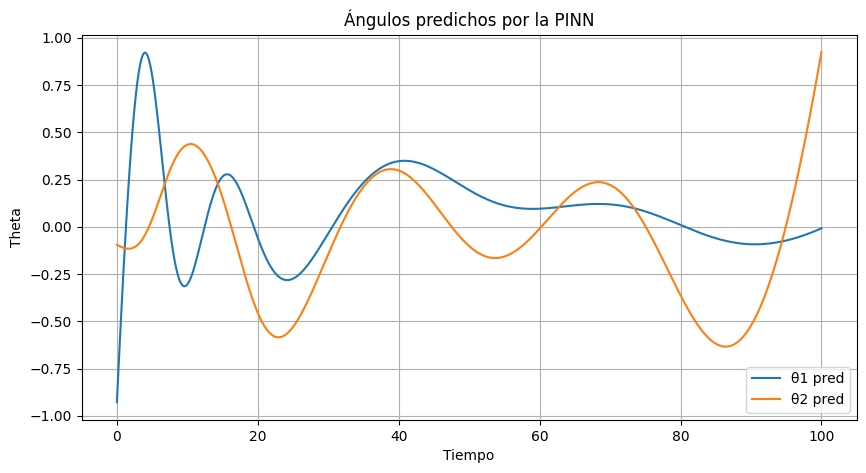

In [12]:
model.eval()


# PREDICCIÓN

t_norm.requires_grad_(True)

theta_pred, _, _ = pf.time_derivatives(model, t_norm)


# DESNORMALIZAR

theta_pred_real = theta_pred * theta_std + theta_mean


# A NUMPY

t_np = t.detach().cpu().numpy()
theta_pred_np = theta_pred_real.detach().cpu().numpy()


# PLOT (SOLO PREDICCIÓN)

plt.figure(figsize=(10,5))

plt.plot(t_np, theta_pred_np[:,0], label="θ1 pred")
plt.plot(t_np, theta_pred_np[:,1], label="θ2 pred")

plt.title("Ángulos predichos por la PINN")
plt.xlabel("Tiempo")
plt.ylabel("Theta")
plt.legend()
plt.grid()

plt.show()